In [ ]:
# !pip install ipykernel
# !pip install transformers datasets matplotlib scikit-learn beautifulsoup4 trl pandas torch==2.8 peft liger-kernel
# !pip install flash-attn --no-build-isolation 

In [ ]:
# !pip install trl liger-kernel

In [1]:
import os
GPU_DEVICES = [0]

os.environ['HF_HUB_DISABLE_XET'] = '1'
os.environ['TOKENIZERS_PARALLELISM'] = 'true'
os.environ["CUDA_VISIBLE_DEVICES"] = ",".join([str(i) for i in GPU_DEVICES])

In [2]:
import re
import random

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm

from bs4 import BeautifulSoup, Comment
from datasets import load_dataset, concatenate_datasets, Dataset
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    set_seed,
)
from trl import SFTTrainer, SFTConfig
from peft import LoraConfig
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [3]:
def set_all_seeds(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    set_seed(seed)

    # Makes CUDA deterministic (optional)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_all_seeds(42)

In [4]:
N_SAMPLES = 10000

stream = load_dataset("phreshphish/phreshphish", split="train", streaming=True)
sampled = Dataset.from_list(list(stream.take(N_SAMPLES)))
print(f"Sampled {len(sampled)} examples")
print(sampled[0])

Resolving data files:   0%|          | 0/56 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/21 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/56 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/21 [00:00<?, ?it/s]

Sampled 10000 examples
{'sha256': 'e5bf57080abb02f77b6f1767a26c19f2ea026d1d553cb8c44b61344ce248a3a3', 'url': 'https://www.lifeonthemediterranean.com/portofino-italy-worth-a-visit/', 'label': 'benign', 'target': None, 'date': datetime.date(2025, 8, 3), 'lang': 'en', 'lang_score': 0.9433812499046326, 'html': '<html lang="en-US"><head><meta charset="UTF-8"><meta name="viewport" content="width=device-width, initial-scale=1"><link rel="profile" href="https://gmpg.org/xfn/11"> <!-- [BEGIN] Metadata added via All-Meta-Tags plugin by Space X-Chimp ( https://www.spacexchimp.com ) --><meta name="p:domain_verify" content="https://www.pinterest.fr/lifeonthemediterranean/"><link rel="author" href="https://plus.google.com/+LifeOnTheMediterranean"><meta name="article:publisher" content="https://www.facebook.com/LifeOnTheMed/"><meta name="twitter:site" content="@LifeOnTheMedSea"><meta name="twitter:creator" content="@LifeOnTheMedSea"><meta name="author" content="Maureen McDermott"><meta name="designer

In [5]:
print(f"=== Raw sampled dataset ===")
print(f"Total samples: {len(sampled)}")
print(f"Columns: {sampled.column_names}")
lang_counts = pd.Series(sampled['lang']).value_counts()
english_count = lang_counts.get('en', 0)
print(f"English: {english_count} ({english_count/len(sampled)*100:.1f}%) | Other languages: {len(sampled) - english_count}")
print(f"Labels: {pd.Series(sampled['label']).value_counts().to_string()}")
print()

dataset = sampled.filter(lambda x: x["lang"] == "en")
non_english_count = len(sampled) - len(dataset)
print(f"=== After language filter ===")
print(f"Kept: {len(dataset)} English | Removed: {non_english_count} non-English ({non_english_count/len(sampled)*100:.1f}%)")
print(f"Labels: {pd.Series(dataset['label']).value_counts().to_string()}")

=== Raw sampled dataset ===
Total samples: 10000
Columns: ['sha256', 'url', 'label', 'target', 'date', 'lang', 'lang_score', 'html']
English: 8350 (83.5%) | Other languages: 1650
Labels: benign    5525
phish     4475



Filter:   0%|          | 0/10000 [00:00<?, ? examples/s]

=== After language filter ===
Kept: 8350 English | Removed: 1650 non-English (16.5%)
Labels: benign    4915
phish     3435


In [6]:
drop_cols = ["sha256", "target", "date", "lang", "lang_score"]
dataset = dataset.remove_columns(drop_cols)
print(f"Removed columns: {drop_cols}")
print(f"Remaining columns: {dataset.column_names}")
print(f"Total samples: {len(dataset)}")

Removed columns: ['sha256', 'target', 'date', 'lang', 'lang_score']
Remaining columns: ['url', 'label', 'html']
Total samples: 8350


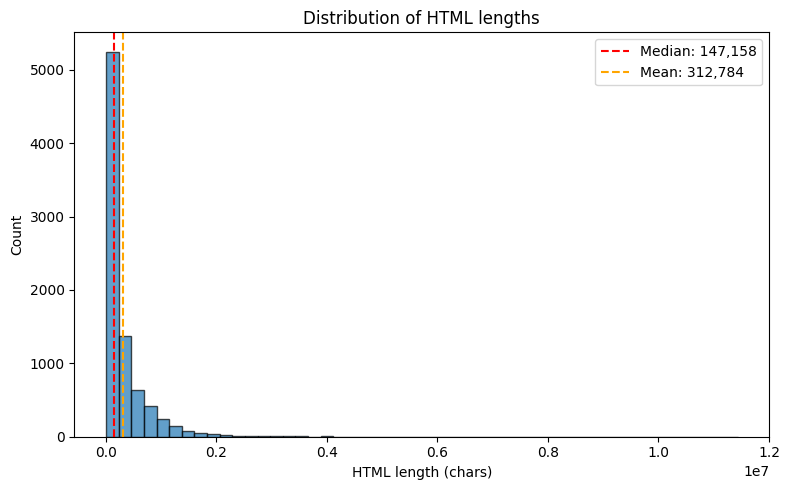

Min: 62 | Max: 11,431,117 | Median: 147,158 | Mean: 312,784


In [7]:
def plot_html_length_distribution(ds):
    html_lengths = [len(x) for x in ds["html"]]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(html_lengths, bins=50, edgecolor="black", alpha=0.7)
    ax.set_xlabel("HTML length (chars)")
    ax.set_ylabel("Count")
    ax.set_title("Distribution of HTML lengths")
    ax.axvline(np.median(html_lengths), color="red", linestyle="--", label=f"Median: {np.median(html_lengths):,.0f}")
    ax.axvline(np.mean(html_lengths), color="orange", linestyle="--", label=f"Mean: {np.mean(html_lengths):,.0f}")
    ax.legend()
    plt.tight_layout()
    plt.show()

    print(f"Min: {min(html_lengths):,} | Max: {max(html_lengths):,} | Median: {np.median(html_lengths):,.0f} | Mean: {np.mean(html_lengths):,.0f}")


plot_html_length_distribution(dataset)

In [ ]:
KEEP_TAGS = {"title", "meta", "form", "input", "button", "select", "textarea", "a", "img", "iframe", "label", "h1", "h2", "h3"}
KEEP_ATTRS = {"href", "src", "action", "method", "type", "name", "placeholder", "alt", "content", "value", "target"}

def clean_html(raw_html):
    soup = BeautifulSoup(raw_html, "html.parser")

    for tag in soup(["script", "style", "noscript"]):
        tag.decompose()
    for comment in soup.find_all(string=lambda t: isinstance(t, Comment)):
        comment.extract()

    kept_parts = []
    for tag in soup.find_all(KEEP_TAGS):
        filtered_attrs = {k: v for k, v in tag.attrs.items() if k in KEEP_ATTRS}
        tag.attrs = filtered_attrs
        for child in tag.find_all(True):
            child_attrs = {k: v for k, v in child.attrs.items() if k in KEEP_ATTRS}
            child.attrs = child_attrs
        kept_parts.append(str(tag))

    return "\n".join(kept_parts)

def clean_html_batch(examples):
    examples["html"] = [clean_html(html) for html in examples["html"]]
    return examples

original_lengths = [len(x) for x in dataset["html"]]
dataset = dataset.map(clean_html_batch, batched=True, batch_size=16, num_proc=os.cpu_count())
cleaned_lengths = [len(x) for x in dataset["html"]]

print(f"=== HTML Cleaning Results ===")
print(f"Avg length before: {np.mean(original_lengths):,.0f} chars")
print(f"Avg length after:  {np.mean(cleaned_lengths):,.0f} chars")
print(f"Avg reduction:     {(1 - np.mean(cleaned_lengths)/np.mean(original_lengths))*100:.1f}%")

Setting TOKENIZERS_PARALLELISM=false for forked processes.


Map (num_proc=224):   0%|          | 0/8350 [00:00<?, ? examples/s]

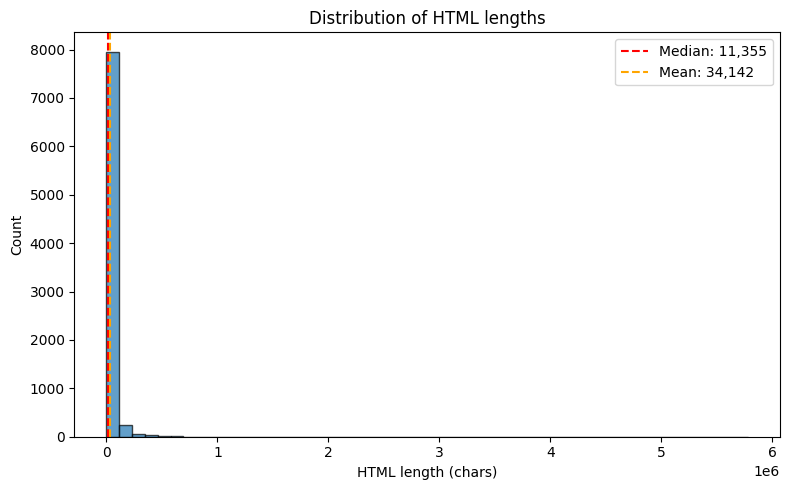

Min: 0 | Max: 5,779,524 | Median: 11,355 | Mean: 34,142


In [ ]:
plot_html_length_distribution(dataset)

In [ ]:
MAX_HTML_LEN = 20_000

before_count = len(dataset)
dataset = dataset.filter(lambda x: len(x["html"]) <= MAX_HTML_LEN)
print(f"=== HTML length filter ===")
print(f"Filtered HTML > {MAX_HTML_LEN:,} chars: {before_count} → {len(dataset)} samples (removed {before_count - len(dataset)})")
print(f"Labels: {pd.Series(dataset['label']).value_counts().to_string()}")
print()

benign = dataset.filter(lambda x: x["label"] == "benign")
phish = dataset.filter(lambda x: x["label"] == "phish")
min_count = min(len(benign), len(phish))

print(f"=== Balancing ===")
print(f"Before: benign={len(benign)}, phish={len(phish)}")
print(f"Downsampling to {min_count} per class")

benign = benign.shuffle(seed=42).select(range(min_count))
phish = phish.shuffle(seed=42).select(range(min_count))
balanced = concatenate_datasets([benign, phish]).shuffle(seed=42)

print()
print(f"=== Final balanced dataset ===")
print(f"Total: {len(balanced)} samples")
print(f"Labels: {pd.Series(balanced['label']).value_counts().to_string()}")

Filter:   0%|          | 0/8350 [00:00<?, ? examples/s]

=== HTML length filter ===
Filtered HTML > 20,000 chars: 8350 → 5063 samples (removed 3287)
Labels: phish     3120
benign    1943



Filter:   0%|          | 0/5063 [00:00<?, ? examples/s]

Filter:   0%|          | 0/5063 [00:00<?, ? examples/s]

=== Balancing ===
Before: benign=1943, phish=3120
Downsampling to 1943 per class

=== Final balanced dataset ===
Total: 3886 samples
Labels: benign    1943
phish     1943


In [ ]:
train_test = balanced.train_test_split(test_size=0.2, seed=42)
train_ds = train_test["train"]
test_val = train_test["test"].train_test_split(test_size=0.5, seed=42)
val_ds = test_val["train"]
test_ds = test_val["test"]

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")
for name, ds in [("Train", train_ds), ("Val", val_ds), ("Test", test_ds)]:
    counts = pd.Series(ds["label"]).value_counts()
    print(f"  {name}: benign={counts.get('benign', 0)}, phish={counts.get('phish', 0)}")

Train: 3108 | Val: 389 | Test: 389
  Train: benign=1570, phish=1538
  Val: benign=187, phish=202
  Test: benign=186, phish=203


In [ ]:
# Load Tokenizer and Model
model_id = "Qwen/Qwen2.5-0.5B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(
    model_id, attn_implementation="sdpa", torch_dtype=torch.bfloat16,
).to("cuda")
model = torch.compile(model)

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

In [ ]:
prompt_template = """Analyze the following webpage and determine if it is a phishing page or a benign (legitimate) page.

URL: {url}

HTML content:
{html}

Classify this webpage as either "phish" or "benign". Output your prediction in XML format: <prediction>phish</prediction> or <prediction>benign</prediction>"""

def preprocess_function(examples):
    urls = examples["url"]
    htmls = examples["html"]
    labels = examples["label"]

    prompts = [prompt_template.format(url=url, html=html) for url, html in zip(urls, htmls)]

    messages = [
        [
            {"role": "user", "content": prompt},
            {"role": "assistant", "content": f"<prediction>{label}</prediction>"},
        ]
        for prompt, label in zip(prompts, labels)
    ]

    return {"messages": messages}


In [ ]:
train_ds = train_ds.map(preprocess_function, batched=True)
val_ds = val_ds.map(preprocess_function, batched=True)
test_ds = test_ds.map(preprocess_function, batched=True)

print("Sample message:")
for msg in train_ds[0]["messages"]:
    content_preview = msg["content"][:300] + "..." if len(msg["content"]) > 300 else msg["content"]
    print(f"  [{msg['role']}]: {content_preview}")

Map:   0%|          | 0/3108 [00:00<?, ? examples/s]

Map:   0%|          | 0/389 [00:00<?, ? examples/s]

Map:   0%|          | 0/389 [00:00<?, ? examples/s]

Sample message:
  [user]: Analyze the following webpage and determine if it is a phishing page or a benign (legitimate) page.

URL: https://www.britannica.com/money/Peter-Thiel

HTML content:
<meta/>
<meta content="width=device-width, initial-scale=1" name="viewport"/>
<title>Peter Thiel | Biography &amp; Facts | Britannica ...
  [assistant]: <prediction>benign</prediction>


In [ ]:
train_ds[0]

{'sha256': '28d57c69897f2e89203c31489881e095252e2f1906d94bc5c56767dc7525aa63',
 'url': 'https://www.britannica.com/money/Peter-Thiel',
 'label': 'benign',
 'target': None,
 'date': datetime.date(2024, 8, 9),
 'lang': 'en',
 'lang_score': 0.9242768883705139,
 'html': '<meta/>\n<meta content="width=device-width, initial-scale=1" name="viewport"/>\n<title>Peter Thiel | Biography &amp; Facts | Britannica Money</title>\n<meta content="Peter Thiel, German American entrepreneur and business executive who helped found PayPal and Palantir Technologies." name="description"/>\n<meta content="Britannica Money"/>\n<meta content="Peter Thiel, German American entrepreneur and business executive who helped found PayPal and Palantir Technologies."/>\n<meta content="image/png"/>\n<meta content="595"/>\n<meta content="596"/>\n<meta content="Britannica thistle\n"/>\n<meta content="https://www.britannica.com/money/money/opengraph-image.png?0ca1ca22e32fe0d6"/>\n<meta content="summary_large_image" name="twit

In [ ]:
def evaluate_model(model, tokenizer, eval_ds, batch_size=32, max_new_tokens=128):
    model.eval()
    responses = []
    labels = []
    tokenizer.padding_side = "left"

    with torch.inference_mode():
        for start_idx in tqdm(range(0, len(eval_ds), batch_size)):
            end_idx = min(start_idx + batch_size, len(eval_ds))

            batch_messages = [eval_ds[i]["messages"][:1] for i in range(start_idx, end_idx)]
            batch_labels = [eval_ds[i]["label"] for i in range(start_idx, end_idx)]

            texts = [
                tokenizer.apply_chat_template(
                    messages,
                    tokenize=False,
                    add_generation_prompt=True,
                )
                for messages in batch_messages
            ]

            model_inputs = tokenizer(
                texts,
                return_tensors="pt",
                padding=True,
            ).to(model.device)

            generated_ids = model.generate(
                **model_inputs,
                max_new_tokens=max_new_tokens,
                temperature=0.0,
                do_sample=False,
                pad_token_id=tokenizer.pad_token_id,
            )

            generated_ids = [
                output_ids[len(input_ids):]
                for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids)
            ]

            batch_responses = tokenizer.batch_decode(
                generated_ids,
                skip_special_tokens=True,
            )

            responses.extend(batch_responses)
            labels.extend(batch_labels)

    def parse_prediction(response):
        match = re.search(r"<prediction>(.*?)</prediction>", response)
        return match.group(1).strip().lower() if match else response.strip().lower()

    parsed = [parse_prediction(r) for r in responses]
    acc = accuracy_score(labels, parsed)
    valid_labels = [l for l, p in zip(labels, parsed) if p in ("phish", "benign")]
    valid_responses = [p for p in parsed if p in ("phish", "benign")]
    invalid_count = len(parsed) - len(valid_responses)

    print(f"Accuracy:  {100 * acc:.2f}%")
    if valid_responses:
        print(f"Precision: {100 * precision_score(valid_labels, valid_responses, pos_label='phish'):.2f}%")
        print(f"Recall:    {100 * recall_score(valid_labels, valid_responses, pos_label='phish'):.2f}%")
        print(f"F1:        {100 * f1_score(valid_labels, valid_responses, pos_label='phish'):.2f}%")
        print(f"\nConfusion matrix (rows=true, cols=pred):")
        cm = confusion_matrix(valid_labels, valid_responses, labels=["benign", "phish"])
        print(pd.DataFrame(cm, index=["true_benign", "true_phish"], columns=["pred_benign", "pred_phish"]))
    if invalid_count > 0:
        print(f"\nInvalid responses: {invalid_count}/{len(responses)}")
        print(f"Examples: {[r for r, p in zip(responses, parsed) if p not in ('phish', 'benign')][:5]}")

    return {
        "responses": responses,
        "parsed": parsed,
        "labels": labels,
        "accuracy": acc,
    }


In [ ]:
results = evaluate_model(model, tokenizer, val_ds)

  0%|          | 0/13 [00:00<?, ?it/s]

100%|██████████| 13/13 [01:11<00:00,  5.52s/it]

Accuracy:  42.67%
Precision: 0.00%
Recall:    0.00%
F1:        0.00%

Confusion matrix (rows=true, cols=pred):
             pred_benign  pred_phish
true_benign          166           0
true_phish           194           0

Invalid responses: 29/389
Examples: ['To analyze whether the given webpage is classified as "phish" or "benign," I\'ll follow these steps:\n\n1. **Check for Phishing Elements**: Look for any elements that might indicate a phishing attempt.\n2. **Verify Legitimacy**: Ensure the URL and other details are correct and relevant to the site\'s purpose.\n3. **Evaluate Content**: Check the HTML content for any suspicious patterns or links.\n\nLet\'s start with the first step:\n\n### Step 1: Check for Phishing Elements\nThe provided HTML content does not contain any obvious phishing elements such as hidden forms, malicious scripts, or deceptive URLs. The', '<prediction>benevolent</prediction>', '```xml\n<prediction>benevolent</prediction>\n```', '```xml\n<prediction>benevolen


/home/elad/mlprague2026/mlprague_venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [ ]:
extra_kwargs = {
    "optim": "adamw_torch_fused",
    "learning_rate": 3e-04,
    "lr_scheduler_type": "constant_with_warmup",
    "max_grad_norm": 0.2,
    "warmup_steps": 5,
    "weight_decay": 0.1,

    "per_device_train_batch_size": 4,
    "per_device_eval_batch_size": 4,
    "gradient_accumulation_steps": 4,
    "max_steps": 100
}

peft_config = None # or peft_config = LoraConfig(???)


training_args = SFTConfig(
    output_dir="./results",    
    eval_strategy="steps",
    eval_steps=25,                  
    logging_strategy="steps",
    logging_steps=25,                   
    save_strategy="no",
    logging_dir="./logs",
    max_length=4096,
    packing=True,
    seed=42,
    data_seed=42,
    report_to="none",
    **extra_kwargs
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
# Trainer Setup
trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    peft_config=peft_config,
)
trainer.can_return_loss = True

[RANK 0] Padding-free training is enabled, but the attention implementation is not set to a supported flash attention variant. Padding-free training flattens batches into a single sequence, and only the following implementations are known to reliably support this: flash_attention_2, flash_attention_3, kernels-community/flash-attn2, kernels-community/flash-attn3, kernels-community/vllm-flash-attn3. Using other implementations may lead to unexpected behavior. To ensure compatibility, set `attn_implementation` in the model configuration to one of these supported options or verify that your attention mechanism can handle flattened sequences.
[RANK 0] You are using packing, but the attention implementation is not set to a supported flash attention variant. Packing gathers multiple samples into a single sequence, and only the following implementations are known to reliably support this: flash_attention_2, flash_attention_3, kernels-community/flash-attn2, kernels-community/flash-attn3, kernel

Tokenizing train dataset:   0%|          | 0/3108 [00:00<?, ? examples/s]

Packing train dataset:   0%|          | 0/3108 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/389 [00:00<?, ? examples/s]

Packing eval dataset:   0%|          | 0/389 [00:00<?, ? examples/s]

In [ ]:
trainer.train()

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss,Validation Loss
25,2.408696,1.379250
50,1.213549,1.175244
75,1.123525,1.116862


TrainOutput(global_step=75, training_loss=1.5819233957926433, metrics={'train_runtime': 456.1884, 'train_samples_per_second': 2.63, 'train_steps_per_second': 0.164, 'total_flos': 1.0519277602040064e+16, 'train_loss': 1.5819233957926433})

In [ ]:
results = evaluate_model(model, tokenizer, val_ds)

100%|██████████| 13/13 [00:38<00:00,  2.95s/it]

Accuracy:  76.09%
Precision: 100.00%
Recall:    53.96%
F1:        70.10%

Confusion matrix (rows=true, cols=pred):
             pred_benign  pred_phish
true_benign          187           0
true_phish            93         109


In [ ]:
results = evaluate_model(model, tokenizer, test_ds)

100%|██████████| 13/13 [00:35<00:00,  2.71s/it]

Accuracy:  77.12%
Precision: 98.31%
Recall:    57.14%
F1:        72.27%

Confusion matrix (rows=true, cols=pred):
             pred_benign  pred_phish
true_benign          184           2
true_phish            87         116
